In [8]:
import datetime
now = datetime.datetime.now()
print(f"Última actualización de este notebook: {now}")

Última actualización de este notebook: 2026-03-13 12:36:23.800538


# Superficie de humedales urbanos protegidos

Este indicador nacional cuantifica la superficie total (en hectáreas) de ecosistemas acuáticos reconocidos y protegidos oficialmente bajo la figura legal de **Humedal Urbano**. Su objetivo es evaluar el cumplimiento de la **Meta Nacional I.3**, la cual establece que al año 2026 el país debe alcanzar entre **14.000 y 17.000 hectáreas** de estos ecosistemas declarados. El reconocimiento formal busca salvaguardar la biodiversidad urbana, asegurar la provisión de servicios ecosistémicos (como la mitigación de inundaciones y la regulación térmica) e integrar estos humedales como infraestructura ecológica dentro de los Instrumentos de Planificación Territorial (IPT).

El acceso a la planilla de datos del indicador se encuentra disponible [aquí](https://docs.google.com/spreadsheets/d/17ST-Nt8obj0PmBMIfztGl-7Kk0ntBVkn/edit?usp=drive_link&ouid=103438392959464183742&rtpof=true&sd=true).

## Metodología de Cálculo
El indicador se calcula mediante la suma espacial de las hectáreas correspondientes a los polígonos de humedales que han sido declarados oficialmente bajo el amparo de la Ley N° 21.202, ya sea por solicitud municipal o de oficio por el Ministerio del Medio Ambiente. Para asegurar la exactitud del cálculo, el indicador contabiliza exclusivamente aquellos humedales que mantienen su vigencia legal, excluyendo las superficies de las declaratorias que hayan sufrido procesos de retrotracción administrativa o judicial.


In [9]:
import math
import time
import requests
import pandas as pd
import geopandas as gpd
from shapely.geometry import shape
import matplotlib.pyplot as plt
import numpy as np


# Capa 1: Observación y recolección

## Fuentes de datos utilizadas
La fuente oficial para la cuantificación de este indicador es la capa espacial de **Humedales Urbanos** alojada y publicada en el visor del **Sistema de Información de Biodiversidad (SIMBIO)** del Ministerio del Medio Ambiente. Adicionalmente, los avances en la transversalización de esta política se respaldan en instrumentos complementarios, como la guía de **“Estándares para la Protección y Evaluación de Impacto Ambiental en Humedales Urbanos para Obras de Infraestructura Pública” (MOP, 2020)**.

In [10]:
# Endpoint ArcGIS REST (Layer 1: Humedales Urbanos Declarados)
LAYER_URL = "https://arcgis.mma.gob.cl/server/rest/services/SIMBIO/SIMBIO_HUMEDALES/MapServer/1/query"

# Parámetros base para consulta
BASE_PARAMS = {
    "f": "json",
    "where": "1=1",
    "outFields": "*",
    "returnGeometry": "true",   # cambiar a true
    "outSR": 4326,              # opcional, reproyecta a WGS84
}

# Para evitar bloqueos por cache/CDN a veces ayuda un user-agent explícito
HEADERS = {
    "User-Agent": "Mozilla/5.0 (compatible; BIODATA/1.0; +https://ieb-chile.cl)"
}


In [11]:
import math
import time
import requests
import pandas as pd
import geopandas as gpd
from shapely.geometry import shape

# Obtener total de registros
params_count = dict(BASE_PARAMS)
params_count.update({
    "returnCountOnly": "true",
    "returnGeometry": "false",
})
r = requests.get(LAYER_URL, params=params_count, headers=HEADERS, timeout=120)
r.raise_for_status()
data = r.json()
total = int(data.get("count", 0))
total



138

# Capa 2: Análisis y síntesis

Tabla extraída

In [12]:
# Función para convertir geometría ArcGIS a Shapely
# El output es una tabla que debiese quedar implementada como base de datos con metadatos para el control de verisones y cambios en la información, pero por ahora se deja como un dataframe para 
# facilitar su uso en análisis posteriores.

from shapely.geometry import Point, MultiPoint, LineString, MultiLineString, Polygon, MultiPolygon

def arcgis_geom_to_shapely(geom):
    if not geom:
        return None
    if "x" in geom and "y" in geom:
        return Point(geom["x"], geom["y"])
    if "points" in geom:
        return MultiPoint(geom["points"])
    if "paths" in geom:
        paths = geom["paths"]
        if len(paths) == 1:
            return LineString(paths[0])
        return MultiLineString(paths)
    if "rings" in geom:
        rings = geom["rings"]
        if len(rings) == 1:
            return Polygon(rings[0])
        return Polygon(rings[0], holes=rings[1:])
    return None

def fetch_page(offset: int, page_size: int = 2000) -> gpd.GeoDataFrame:
    params = dict(BASE_PARAMS)
    params.update({
        "resultOffset": offset,
        "resultRecordCount": page_size,
        "orderByFields": "OBJECTID ASC",
    })
    r = requests.get(LAYER_URL, params=params, headers=HEADERS, timeout=120)
    r.raise_for_status()
    data = r.json()

    if "error" in data:
        raise RuntimeError(f"Error ArcGIS: {data['error']}")

    feats = data.get("features", [])
    rows = []
    for f in feats:
        attrs = f.get("attributes", {})
        geom = f.get("geometry")
        attrs["geometry"] = arcgis_geom_to_shapely(geom)
        rows.append(attrs)

    return gpd.GeoDataFrame(rows, geometry="geometry", crs="EPSG:4326")

PAGE_SIZE = 2000
pages = math.ceil(total / PAGE_SIZE)

gdfs = []
for i in range(pages):
    offset = i * PAGE_SIZE
    gdf_i = fetch_page(offset, PAGE_SIZE)
    print(f"Página {i+1}/{pages}: {len(gdf_i)} filas (offset={offset})")
    gdfs.append(gdf_i)
    time.sleep(0.2)

gdf = gpd.GeoDataFrame(pd.concat(gdfs, ignore_index=True)) if gdfs else gpd.GeoDataFrame()

# Reparar geometrías si es necesario
try:
    gdf["geometry"] = gdf.geometry.make_valid()
except Exception:
    gdf["geometry"] = gdf.geometry.buffer(0)

# Calcular en CRS en metros (ajusta según zona)
gdf_m = gdf.to_crs(32719)  # UTM 19S para Chile central; usa 32718 si es más al norte

gdf["Shape_Area"] = gdf_m.area
gdf["Shape_Leng"] = gdf_m.length

gdf.head()



Página 1/1: 138 filas (offset=0)


,COD_HUM_M,NOMBRE,COMUNA,PROVINCIA,REGION,HECTAREAS,PROCESO,RESOLUCION,URL_RES_BCN,OBJECTID,URL_SIMBIO,geometry,Shape_Area,Shape_Leng
0,HU-0012,Aguada La Chimba,ANTOFAGASTA,ANTOFAGASTA,REGIÓN DE ANTOFAGASTA,1.005898,O,R.E. N°0787/2021,http://bcn.cl/2ul3k,1,https://sistemahumedales.mma.gob.cl/OficioHU/D...,"MULTIPOLYGON (((-70.39972 -23.56391, -70.39967...",1.005601e+04,888.750651
1,HU-0031,Baños Morales,SAN JOSÉ DE MAIPO,CORDILLERA,REGIÓN METROPOLITANA DE SANTIAGO,2.809060,O,R.E. N°0990/2021,http://bcn.cl/2svqw,2,https://sistemahumedales.mma.gob.cl/OficioHU/D...,"POLYGON ((-70.06194 -33.82134, -70.06194 -33.8...",2.807481e+04,1482.898397
2,HU-0029,Bucalemu,PAREDONES,CARDENAL CARO,REGIÓN DEL LIBERTADOR GENERAL BERNARDO O'HIGGINS,279.376802,O,R.E. N°0982/2021,http://bcn.cl/2ul4c,3,https://sistemahumedales.mma.gob.cl/OficioHU/D...,"MULTIPOLYGON (((-72.02191 -34.65493, -72.02194...",2.796775e+06,21404.983257
3,HU-0010,Circuito Humedales Pudeto Bajo,ANCUD,CHILOÉ,REGIÓN DE LOS LAGOS,37.247461,M,RE N° 784/ 2021,http://bcn.cl/2rcl5,4,https://sistemahumedales.mma.gob.cl/HumedalesU...,"MULTIPOLYGON (((-73.79249 -41.88313, -73.79233...",3.736260e+05,7589.915449
4,HU-0027,El Avellano,LOS ÁNGELES,BIOBÍO,REGIÓN DEL BIOBÍO,6.617904,O,RE N° 921/ 2021,http://bcn.cl/2sspa,5,https://sistemahumedales.mma.gob.cl/OficioHU/D...,"POLYGON ((-72.33965 -37.43911, -72.3397 -37.43...",6.626825e+04,1746.500679


In [13]:
df=gdf
df["anio_publicacion"] = (
    df["RESOLUCION"]
    .str.extract(r"/\s*(\d{4})", expand=False)
    .astype("Int64")
)

df["anio_publicacion"].isna().any()
df["anio_publicacion"].agg(["min", "max"])


min    2021
max    2026
Name: anio_publicacion, dtype: int64

# Capa 3: Repporte Digital
## Resultados

In [24]:
# desde df se va a calcular el total de superficie protegida para mostrarla como sin decimales

total_superficie = df["Shape_Area"].sum() / 10000  # convertir a hectáreas
total_superficie = int(total_superficie)    


**Indicador 1** Superficie acumulada de Humedales Urbanos protegidos

In [21]:
df["HECTAREAS"] = pd.to_numeric(df["HECTAREAS"], errors="coerce")

tabla_anual = (
    df
    .groupby("anio_publicacion", as_index=False)["HECTAREAS"]
    .sum()
    .sort_values("anio_publicacion")
)

tabla_anual["hectareas_acumuladas"] = (
    tabla_anual["HECTAREAS"].cumsum()
)
tabla_anual

,anio_publicacion,HECTAREAS,hectareas_acumuladas
0,2021,5471.973004,5471.973004
1,2022,2026.481850,7498.454854
2,2023,2020.685909,9519.140762
3,2024,1197.919144,10717.059907
4,2025,5668.585116,16385.645023
5,2026,1377.224371,17762.869393


In [25]:
from IPython.display import Markdown as md
text = f""" 
A la fecha de reporte, el Estado de Chile ha logrado cumplir y posicionarse en el límite superior de la meta nacional:
- Superficie Protegida: Se registran {total_superficie} hectáreas de humedales urbanos reconocidos que mantienen plena vigencia legal.
- Número de Humedales: El país cuenta actualmente con 137 humedales urbanos activos (de un total de 147 declaraciones originales).
- Evolución Temporal: Desde la promulgación de la ley, la superficie acumulada ha experimentado un crecimiento sostenido: 5.471,97 ha (2021); 7.498,45 ha (2022); 9.519,14 ha (2023); 10.717,06 ha (2024); logrando el gran salto a las 16.848,28 ha en 2025."""
md(text)

 
A la fecha de reporte, el Estado de Chile ha logrado cumplir y posicionarse en el límite superior de la meta nacional:
- Superficie Protegida: Se registran 17777 hectáreas de humedales urbanos reconocidos que mantienen plena vigencia legal.
- Número de Humedales: El país cuenta actualmente con 137 humedales urbanos activos (de un total de 147 declaraciones originales).
- Evolución Temporal: Desde la promulgación de la ley, la superficie acumulada ha experimentado un crecimiento sostenido: 5.471,97 ha (2021); 7.498,45 ha (2022); 9.519,14 ha (2023); 10.717,06 ha (2024); logrando el gran salto a las 16.848,28 ha en 2025.

In [181]:
#escribir tabla anual a Excel
tabla_anual.to_excel("I_3_humedales_urbanos_tabla_anual.xlsx", index=False)

In [182]:
data=gdf.to_crs(epsg=32719)

REGION = {
    'REGIÓN DE TARAPACÁ': "TA",
    'REGIÓN DE ANTOFAGASTA': "AN",
    'REGIÓN DE ATACAMA': "AT",
    'REGIÓN DE COQUIMBO': "CO",
    'REGIÓN DE VALPARAÍSO': "VA",
    'REGIÓN METROPOLITANA DE SANTIAGO': "RM",
    "REGIÓN DEL LIBERTADOR GENERAL BERNARDO O'HIGGINS": "LI",
    'REGIÓN DEL MAULE': "ML",
    'REGIÓN DEL ÑUBLE': "NB",
    'REGIÓN DEL BIOBÍO': "BI",
    'REGIÓN DE LA ARAUCANÍA': "AR",
    'REGIÓN DE LOS RÍOS': "LR",
    'REGIÓN DE LOS LAGOS': "LL",
    'REGIÓN DE AYSÉN DEL GENERAL CARLOS IBÁÑEZ DEL CAMPO': "AI",
    'REGIÓN DE MAGALLANES Y DE LA ANTÁRTICA CHILENA': "MA",
}


In [183]:
data["COD_REG"] = data["REGION"].map(REGION)

In [185]:
data_region = pd.DataFrame(
    list(REGION.items()),
    columns=["Región", "Código Región"]
)
data_region["geometry"] = None
data_region["Hectáreas"] = 0.0
data_region["Hectáreas (geometría)"] = 0.0
data_region["Número de humedales"] = 0


**indicador 2** Superficie de humedales protegidos por región

In [186]:
for region in REGION.values():
    tmp = data[data["COD_REG"] == region]
    tmp_geometry = tmp.geometry.union_all()
    cur_index = data_region[data_region["Código Región"] == region].index[0]
    data_region.loc[cur_index, "geometry"] = tmp_geometry
    data_region.loc[cur_index, "Hectáreas"] = tmp["HECTAREAS"].sum()
    data_region.loc[cur_index, "Hectáreas (geometría)"] = tmp_geometry.area / 10000
    data_region.loc[cur_index, "Número de humedales"] = len(tmp)
    del tmp, tmp_geometry

data_region

,Región,Código Región,geometry,Hectáreas,Hectáreas (geometría),Número de humedales
0,REGIÓN DE TARAPACÁ,TA,"POLYGON ((379881.2673000004 7751351.8057, 3800...",132.612247,132.552911,1
1,REGIÓN DE ANTOFAGASTA,AN,MULTIPOLYGON (((368475.68130000506 7385950.111...,570.779950,570.355680,4
2,REGIÓN DE ATACAMA,AT,MULTIPOLYGON (((323978.13020003936 6839520.413...,361.089372,361.172458,3
3,REGIÓN DE COQUIMBO,CO,MULTIPOLYGON (((262181.99990043906 6441494.999...,35.061596,35.079283,2
4,REGIÓN DE VALPARAÍSO,VA,MULTIPOLYGON (((256639.2197005588 6278312.5846...,1098.997366,1099.503953,25
5,REGIÓN METROPOLITANA DE SANTIAGO,RM,MULTIPOLYGON (((321208.3702000638 6255405.5377...,7756.287895,7756.669481,16
6,REGIÓN DEL LIBERTADOR GENERAL BERNARDO O'HIGGINS,LI,MULTIPOLYGON (((223052.0536014572 6160901.3196...,380.755942,381.145261,5
7,REGIÓN DEL MAULE,ML,"POLYGON ((257338.1775005925 6078380.795800008,...",348.412700,348.639730,1
8,REGIÓN DEL ÑUBLE,NB,MULTIPOLYGON (((193226.07970323006 5925759.366...,1117.538007,1119.581066,7
9,REGIÓN DEL BIOBÍO,BI,MULTIPOLYGON (((113207.42111705709 5806359.772...,2430.442932,2436.526417,25


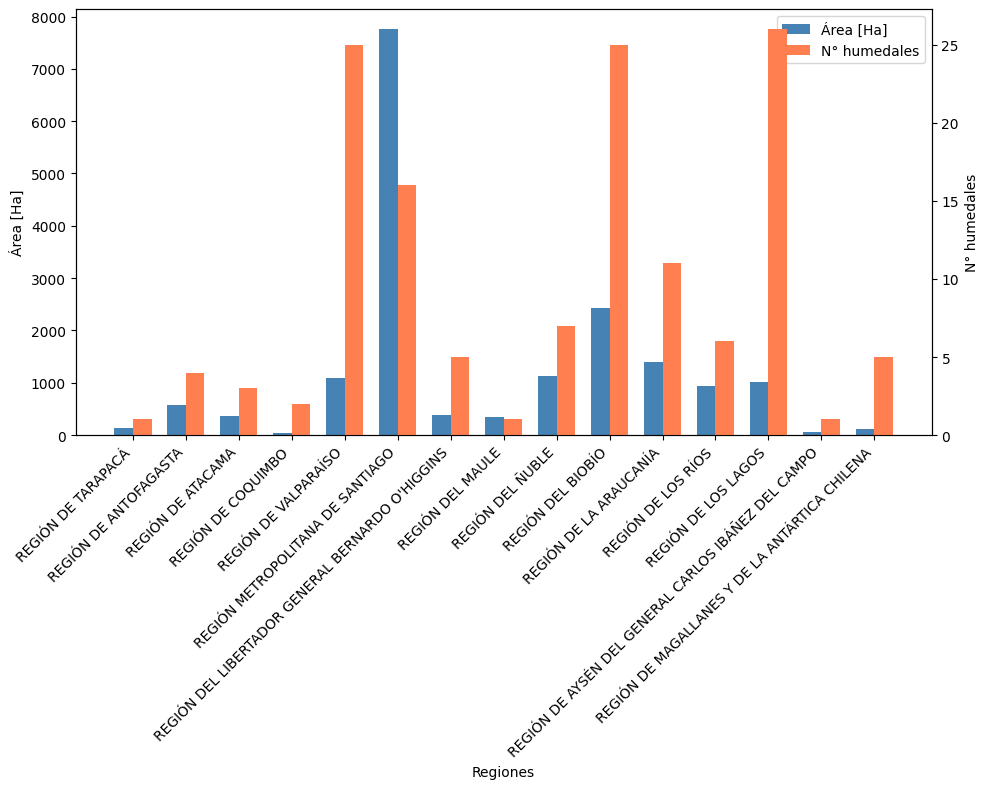

In [187]:
fig, ax = plt.subplots(figsize=(10, 8))

position = np.arange(len(data_region))
width = 0.35

area_bar = ax.bar(position - width / 2, data_region["Hectáreas (geometría)"], width, label="Área [Ha]", color="steelblue")
ax.set_xlabel("Regiones")
ax.set_ylabel("Área [Ha]")

ax2 = ax.twinx()
number_bar = ax2.bar(position + width / 2, data_region["Número de humedales"], width, label="N° humedales", color="coral")
ax2.set_ylabel("N° humedales")

ax.set_xticks(position)
ax.set_xticklabels(data_region["Región"], rotation=45, ha='right')

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.tight_layout()






## Observaciones y brechas




In [26]:
from IPython.display import Markdown as md
total = 17000
text = f""" 
El logro de las **{total_superficie} hectáreas** demuestra una política pública altamente efectiva en su fase de declaración. La **Ley N° 21.202** ha funcionado como un catalizador institucional que trasciende la mera conservación de la biodiversidad, obligando a que cualquier proyecto que pueda afectar a estos ecosistemas ingrese al **Sistema de Evaluación de Impacto Ambiental (SEIA)** y forzando a carteras enfocadas en obras civiles (como el **MOP**) a generar nuevos estándares de infraestructura pública.
"""
md(text)

 
El logro de las **17777 hectáreas** demuestra una política pública altamente efectiva en su fase de declaración. La **Ley N° 21.202** ha funcionado como un catalizador institucional que trasciende la mera conservación de la biodiversidad, obligando a que cualquier proyecto que pueda afectar a estos ecosistemas ingrese al **Sistema de Evaluación de Impacto Ambiental (SEIA)** y forzando a carteras enfocadas en obras civiles (como el **MOP**) a generar nuevos estándares de infraestructura pública.
